In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [6]:
def store_results(path: str, n_rounds: int):
    """This creates a nested dictionary with the replicates and the rounds for each replicate,
    storing the df_sorted_all.csv file within it. The dict is create from the directory hiercarchy 
    in which the results are stored. The input dict must be empty. 
    Please note that the n_rounds value must be written as n_rounds+1 otherwise
    you will lose the last round"""
    d = {}
    for dir in os.listdir(path): #iterate over dir in path given in input 
        if dir.endswith('_rep'): #for iterating over the dir
            d[dir] = {} #empty dict for storing
            for i in range(1, n_rounds): #loop for iterate over rounds
                if path.endswith(('.xlsx', '.xls')):
                    raise RuntimeError(f'The uploaded Dataframe is an excel file, please use a csv format')
                rep_path = os.path.join(path, dir, f'Round{i}')
                d[dir][f'Round{i}']= None
                round_path = os.listdir(rep_path)
                file_path = os.path.join(rep_path, 'df_sorted_all.csv')
                d[dir][f'Round{i}']= pd.read_csv(file_path)
        else:
            raise RuntimeError(f'No directory ends with _rep, please rename your directory')
    return d
EVOLVEPRO_RESULTS = "/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/try_1/"

dict_evolve = store_results(EVOLVEPRO_RESULTS, 11)
print(dict_evolve)

{'1_rep': {'Round1':       Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  \
0              0   R174M  0.355522  0.790948         0.947377   
1              1    P92D  0.337826  0.937027         1.000000   
2              2   T102E  0.184468       NaN              NaN   
3              3   N288D  0.174262       NaN              NaN   
4              4   T304E  0.152692       NaN              NaN   
...          ...     ...       ...       ...              ...   
7443        7443   E271Y -0.976975       NaN              NaN   
7444        7444   E339I -0.984902       NaN              NaN   
7445        7445   P219R -1.002128       NaN              NaN   
7446        7446   E326I -1.041659       NaN              NaN   
7447        7447   G244N -1.308706 -1.838922         0.000000   

      y_actual_binary  dist_metric  std_predictions  
0                 0.0     0.038435              0.0  
1                 0.0     0.026965              0.0  
2                 NaN          NaN  

In [7]:
from evolvepro.src.metrics_functions import load_dataset, enrichment_factor, apk
#def df_metrics()
rounds=[]
for i in range(1,11):
    rounds.append(i)
print(rounds)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/embedding/giacomelli_labels.csv'
hit =1.0
frac = 0.1
k_hit=10
def metrics_calc(labels: str, 
                 dict: dict) -> csv:
    """ This function takes as argument the labels file and a dictionary that stores 
    the results from 3 replicates of Evolvepro to calculate the Enrichment Factor
    and the Average Precision, and the sores the results in a new file csv"""
    
    rep_list = [1, 2, 3] #number of replicates
    #empty list for storing the results
    Rounds = []
    ef_list = []
    ap_list = []
    for r in dict:
        print(r)
        for i in rep_list:
            print(i)
            if r == f'{i}_rep':
                for v in dict[f'{i}_rep']: #Iterates over the first replicate
                    df = dict[f'{i}_rep'][v] #Stores the Rounds dict in a new variable
                    print(v)
                    #print(df)
                    Rounds.append(v)
                    df_round = load_dataset(df, labels, threshold_hit=hit) 
                    print(df_round)
                    ef = enrichment_factor(df_round, fraction=frac)
                    ap = apk(df_round, k=k_hit)
                    ef_list.append(ef)
                    ap_list.append(ap)
                    print(f'Enrichment Factor: {ef}')
                    print(f'Average Precision: {ap}')
                    df_metrics = pd.DataFrame({'Rounds': pd.Series(Rounds), 
                          'ef_1': pd.Series(ef_list),
                          'apk_1':pd.Series(ap_list)})
    df_metrics.to_csv(f'/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/metriche/giaco_metrics.csv',
                            encoding='utf-8', index = False)
    return df_metrics
print(metrics_calc(labels, dict_evolve))

1_rep
1
Round1
      Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  \
0              0   R174M  0.355522  0.790948         0.947377   
1              1    P92D  0.337826  0.937027         1.000000   
2              2   T102E  0.184468       NaN              NaN   
3              3   N288D  0.174262       NaN              NaN   
4              4   T304E  0.152692       NaN              NaN   
...          ...     ...       ...       ...              ...   
7443        7443   E271Y -0.976975       NaN              NaN   
7444        7444   E339I -0.984902       NaN              NaN   
7445        7445   P219R -1.002128       NaN              NaN   
7446        7446   E326I -1.041659       NaN              NaN   
7447        7447   G244N -1.308706 -1.838922         0.000000   

      y_actual_binary  dist_metric  std_predictions  activity  activity_binary  
0                 0.0     0.038435              0.0  0.790948                0  
1                 0.0     0.026965        

In [24]:
labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/embedding/giacomelli_labels.csv'
hit = 1.0
frac = 0.1
k_hit = 10

def metrics_calc(labels: str, results: dict) -> pd.DataFrame:
    """ This function takes as argument the labels file and a dictionary that stores 
    the results from 3 replicates of Evolvepro to calculate the Enrichment Factor
    and the Average Precision, and the sores the results in a new file csv"""
    rep_list = [1, 2, 3]
    rounds = sorted(
        results['1_rep'].keys(),
        key=lambda x: int(''.join(filter(str.isdigit, x))) 
        if any(ch.isdigit() for ch in x) else x)
    print(rounds)
    metrics = {i: {'ef': [], 'apk': []} for i in rep_list}
    print(metrics)
    for round_name in rounds:
        for i in rep_list:
            rep_key = f'{i}_rep'
            df = results[rep_key][round_name]
            df_round = load_dataset(df, labels, threshold_hit=hit)
            ef = enrichment_factor(df_round, fraction=frac)
            ap = apk(df_round, k=k_hit)
            metrics[i]['ef'].append(ef)
            metrics[i]['apk'].append(ap)
    print(df)
    print(metrics)
    df_metrics = pd.DataFrame({
        'Rounds': rounds,
        'ef_1': metrics[1]['ef'], 'apk_1': metrics[1]['apk'],
        'ef_2': metrics[2]['ef'],'apk_2': metrics[2]['apk'],
        'ef_3': metrics[3]['ef'],'apk_3': metrics[3]['apk'],
    })
    df_metrics['ef_mean'] = df_metrics[['ef_1', 'ef_2', 'ef_3']].mean(axis=1, numeric_only=True)
    df_metrics['apk_mean'] = df_metrics[['apk_1', 'apk_2', 'apk_3']].mean(axis=1, numeric_only=True)
    df_metrics['ef_std'] = df_metrics[['ef_1', 'ef_2', 'ef_3']].std(axis=1, numeric_only=True)
    df_metrics['apk_std'] = df_metrics[['apk_1', 'apk_2', 'apk_3']].std(axis=1, numeric_only=True)
    
    return df_metrics
df_metrics = metrics_calc(labels, dict_evolve)
df_metrics.to_csv('/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/metriche/giaco_metrics.csv',
                            encoding='utf-8', index = False)
print(df_metrics)

['Round1', 'Round2', 'Round3', 'Round4', 'Round5', 'Round6', 'Round7', 'Round8', 'Round9', 'Round10']
{1: {'ef': [], 'apk': []}, 2: {'ef': [], 'apk': []}, 3: {'ef': [], 'apk': []}}
      Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  \
0              0   H368M  1.596443  1.821861         0.985097   
1              1   S366I  1.548940  1.877319         1.000000   
2              2   H368F  1.528954  1.681469         0.947370   
3              3   E388N  1.495084  1.558262         0.914260   
4              4   E388Y  1.476135  1.619739         0.930781   
...          ...     ...       ...       ...              ...   
7443        7443   R248L -0.485877       NaN              NaN   
7444        7444   R249D -0.506582       NaN              NaN   
7445        7445   K132E -0.527416       NaN              NaN   
7446        7446   R248C -0.592775 -0.913468         0.250036   
7447        7447   G199W -1.180410 -1.843908         0.000000   

      y_actual_binary  dist_metric  st

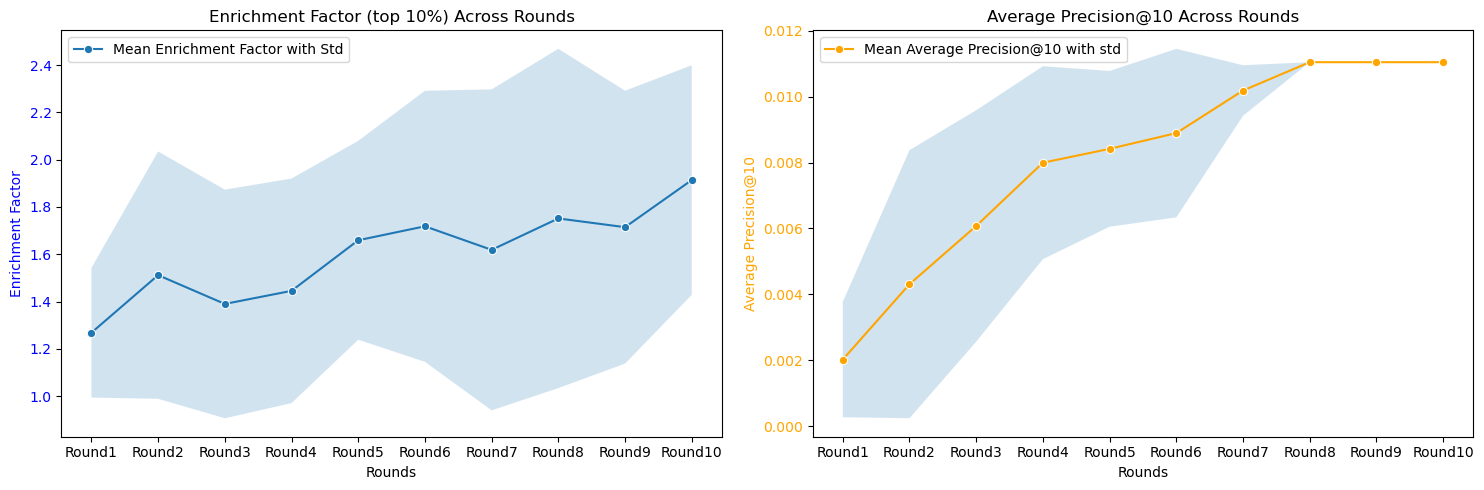

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(15, 5))
sns.lineplot(x=df_metrics['Rounds'], y=df_metrics['ef_mean'], marker='o', 
             label='Mean Enrichment Factor with Std', ax=ax1)
ax1.set_title('Enrichment Factor (top 10%) Across Rounds')
ax1.get_xticks
ax1.set_xlabel('Rounds')
ax1.fill_between(x=df_metrics['Rounds'], y1=  np.subtract(df_metrics['ef_mean'], df_metrics['ef_std']), 
                 y2=np.add(df_metrics['ef_mean'], df_metrics['ef_std']),  alpha=0.2, label='EF STD')
ax1.set_ylabel('Enrichment Factor', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


sns.lineplot(x=df_metrics['Rounds'], y=df_metrics['apk_mean'], marker='o', 
             label='Mean Average Precision@10 with std', ax=ax2, color='orange')
ax2.set_title('Average Precision@10 Across Rounds')
ax2.set_xlabel('Rounds')
ax2.fill_between(x=df_metrics['Rounds'], y1=  np.subtract(df_metrics['apk_mean'], df_metrics['apk_std']), 
                 y2=np.add(df_metrics['apk_mean'], df_metrics['apk_std']),  alpha=0.2, label ='AP STD')
ax2.set_ylabel('Average Precision@10', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
fig.tight_layout()
plt.savefig(
    '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/metriche/giacomelli_metrics_new.png', 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

